In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import cv2
import numpy as np




In [3]:
!pip install kaggle

In [5]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU is available and memory growth is set.")
  except RuntimeError as e:
    print(e)

GPU is available and memory growth is set.


In [ ]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
EPOCHS = 10
DATA_DIR = '/kaggle/input/chest-xray-pneumonia/chest_xray'

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
try:
    train_generator = train_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'train'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    val_generator = val_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'val'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    test_generator = test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'test'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure your dataset is correctly organized at the specified path.")
    exit()

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("\nStarting model training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE
)


Starting model training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 644ms/step - accuracy: 0.7161 - loss: 0.7073 - val_accuracy: 0.8125 - val_loss: 0.6232
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 470ms/step - accuracy: 0.8404 - loss: 0.3635 - val_accuracy: 0.7500 - val_loss: 0.5828
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 475ms/step - accuracy: 0.8656 - loss: 0.3059 - val_accuracy: 0.8750 - val_loss: 0.3923
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 459ms/step - accuracy: 0.8957 - loss: 0.2467 - val_accuracy: 0.8750 - val_loss: 0.3976
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 459ms/step - accuracy: 0.8983 - loss: 0.2467 - val_accuracy: 0.7500 - val_loss: 0.4737
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 461ms/step - accuracy: 0.9069 - loss: 0.2250 - val_accuracy: 0.8125 - val_loss: 0.3959
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 460ms/step - accuracy: 0.9101 - loss: 0.2228 - val_accuracy: 0.8750 - val_loss: 0.4290
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 467ms/step - accuracy: 0.9110 - loss: 

In [ ]:
print("\nEvaluating the model on the test dataset...")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating the model on the test dataset...
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 337ms/step - accuracy: 0.8053 - loss: 0.5046
Test Loss: 0.3324
Test Accuracy: 0.8702


In [ ]:
model_filename = 'pneumonia_detector_model.keras'
print(f"\nSaving the trained model to '{model_filename}'...")
model.save(model_filename)
print("Model saved successfully.")


Saving the trained model to 'pneumonia_detector_model.keras'...
Model saved successfully.


In [ ]:
def predict_pneumonia(image_path, model):
    """
    Predicts whether an X-ray image shows signs of pneumonia or is normal.
    """
    try:
        img = cv2.imread(image_path)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        prediction = model.predict(img)[0][0]
        if prediction > 0.5:
            return f"Pneumonia detected with confidence: {prediction*100:.2f}%"
        else:
            return f"No pneumonia detected with confidence: {(1 - prediction)*100:.2f}%"
    except Exception as e:
        return f"Error during prediction: {e}"

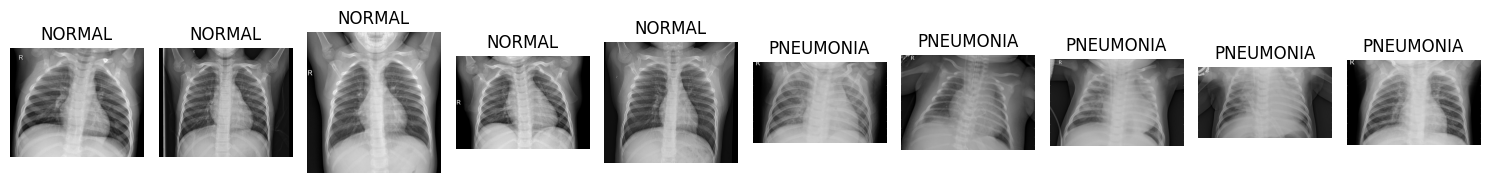

In [ ]:
import matplotlib.pyplot as plt
import random

def display_sample_images(data_dir, num_images=5):
    """Displays a few sample images from the NORMAL and PNEUMONIA classes."""
    normal_dir = os.path.join(data_dir, 'test', 'NORMAL')
    pneumonia_dir = os.path.join(data_dir, 'test', 'PNEUMONIA')

    normal_images = [os.path.join(normal_dir, img) for img in os.listdir(normal_dir) if img.endswith('.jpeg')]
    pneumonia_images = [os.path.join(pneumonia_dir, img) for img in os.listdir(pneumonia_dir) if img.endswith('.jpeg')]

    sample_normal = random.sample(normal_images, min(num_images, len(normal_images)))
    sample_pneumonia = random.sample(pneumonia_images, min(num_images, len(pneumonia_images)))

    plt.figure(figsize=(15, 5))

    for i, img_path in enumerate(sample_normal):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_images * 2, i + 1)
        plt.imshow(img)
        plt.title('NORMAL')
        plt.axis('off')

    for i, img_path in enumerate(sample_pneumonia):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_images * 2, i + num_images + 1)
        plt.imshow(img)
        plt.title('PNEUMONIA')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

display_sample_images(DATA_DIR)

In [ ]:
# Example Usage: Predict on a sample image
sample_image_path = os.path.join(DATA_DIR, 'test', 'PNEUMONIA', os.listdir(os.path.join(DATA_DIR, 'test', 'PNEUMONIA'))[0]) # Using the first pneumonia image in the test set as an example
prediction_result = predict_pneumonia(sample_image_path, model)
print(prediction_result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step
Pneumonia detected with confidence: 98.69%


Saving ACEP_0419_pg15b-350x336.png to ACEP_0419_pg15b-350x336.png
Processing uploaded file: ACEP_0419_pg15b-350x336.png


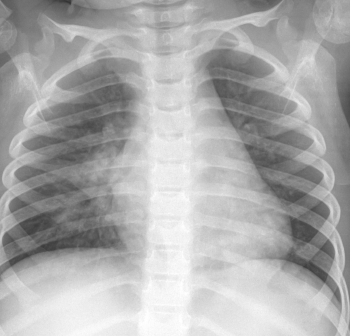

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction for ACEP_0419_pg15b-350x336.png: Pneumonia detected with confidence: 71.68%


In [ ]:
from google.colab import files
from IPython.display import Image, display
import os

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Processing uploaded file: {filename}')
  try:

    display(Image(filename))


    prediction_result = predict_pneumonia(filename, model)
    print(f"Prediction for {filename}: {prediction_result}")

  except Exception as e:
    print(f"Could not process {filename}: {e}")